# Basin-Set Comparison: Megadrought Amplification & Decomposition

Reruns the core megadrought metrics (drought amplification factor,
Q-decline vs. melt-change decomposition, significant-increasing-trend
share) across all three basin definitions AND all three climate
datasets (CR2MET, ERA5, CRU) -- 9 combinations total, so the sensitivity of these
headline numbers to basin choice can be seen directly and presented to
co-authors as the basis for deciding which definition to standardize on.

**Does NOT require rerunning 03 or 04.** Reads `RESULTS.pkl` (from 03,
unaffected by the hierarchy fix) for both `all_glacierized` and
`leaf_only`, and `RESULTS_grouped.pkl` (from 02, already rerun with the
corrected geometric hierarchy) for `grouped_main`. No new simulation.

This was prompted by Cells 27-29 of `megadrought_and_lag_analysis.ipynb`
finding a real discrepancy between originally-reported figures and a
verification rerun (e.g. Q-decline: originally 78-94%, rerun found
57-60%; Central Andes amplification: originally "up to 3.7x", rerun
found median 2.34x with true max 10.69x). The working hypothesis is that
this gap is driven by basin-set choice (nested double-counting vs.
outlet-only vs. leaf-only), not a computational error -- this notebook
tests that directly.


In [1]:
import os, sys, pickle, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

sys.path.insert(0, '/Users/milliespencer/OGGM_CR2_Chile')
from basin_hierarchy_utils import build_containment_maps
from completeness_utils import assess_completeness

BASE        = '/Users/milliespencer/Desktop/CR2_OGGM_Paper'
OUTPUT_ROOT = f'{BASE}/Output'
CAMELS_FULL = f'{BASE}/Full_CAMELS_all_basins/CAMELS_CL_v202201'
OUT_DIR_SUB = f'{OUTPUT_ROOT}/all_chile_results_v2'
OUT_DIR_GRP = f'{OUTPUT_ROOT}/grouped_basin_results'
BOUNDS_PATH = f'{CAMELS_FULL}/camels_cl_boundaries/camels_cl_boundaries.shp'

COMPARISON_DIR = f'{OUTPUT_ROOT}/basin_set_comparison'
os.makedirs(COMPARISON_DIR, exist_ok=True)

YEARS      = list(range(2000, 2020))
BASELINE   = list(range(2000, 2010))
DROUGHT1   = list(range(2010, 2020))
CLUSTERS   = ['OT3','DA1','DA2','DA3','WA1','WA2','WA3','WA4','WA5','WA6']
CENTRAL_ANDES = ['DA1','DA2','DA3']
BASIN_SET_COLORS = {'all_glacierized': '#3498db', 'grouped_main': '#e67e22', 'leaf_only': '#2ecc71'}
BASIN_SET_LABELS = {'all_glacierized': 'All glacierized\n(nested)',
                     'grouped_main':   'Grouped main\n(depth=0)',
                     'leaf_only':      'Leaf-only\n(smallest source)'}


## Load all three basin sets

In [2]:
def _load_q_day():
    q_day = pd.read_csv(f'{CAMELS_FULL}/q_m3s_day.csv', parse_dates=['date'])
    return q_day[(q_day['year'] >= 1999) & (q_day['year'] <= 2019)].copy()


def _gauge_info_from_nested(nested_csv):
    info = {}
    for gauge_id, grp in nested_csv.groupby('gauge_id'):
        info[gauge_id] = {
            'gauge_name':       grp['gauge_name'].iloc[0],
            'rgi_ids':          grp['RGIId'].tolist(),
            'n_glaciers':       len(grp),
            'glacier_area_km2': grp['Area'].sum(),
            'basin_area_km2':   grp['area_km2'].iloc[0],
            'clusters':         sorted(grp['Cluster'].unique().tolist()),
            'cen_lat':          grp['CenLat'].mean(),
            'cen_lon':          grp['CenLon'].mean(),
        }
    return info


def load_basin_set(basin_set):
    """Returns (RESULTS, GAUGE_INFO_FRAC, label) for the given basin set.
    No simulation is run -- everything is read from existing pickles."""

    if basin_set == 'all_glacierized':
        with open(f'{OUT_DIR_SUB}/RESULTS.pkl', 'rb') as f:
            RESULTS = pickle.load(f)
        nested_csv = pd.read_csv(f'{OUT_DIR_SUB}/spatial_join_nested.csv', dtype={'gauge_id': str})
        GAUGE_INFO = _gauge_info_from_nested(nested_csv)

        q_day = _load_q_day()
        gauges_in_results = set(RESULTS['CR2MET'].keys())
        GAUGE_INFO_FRAC = {}
        for gid, info in GAUGE_INFO.items():
            if gid not in gauges_in_results:
                continue
            comp = assess_completeness(q_day, gid, info['cen_lat'])
            if comp['passes']:
                GAUGE_INFO_FRAC[gid] = {**info, 'complete_years': comp['complete_years']}

        label = f'All glacierized sub-basins (nested, n={len(GAUGE_INFO_FRAC)})'

    elif basin_set == 'grouped_main':
        with open(f'{OUT_DIR_GRP}/RESULTS_grouped.pkl', 'rb') as f:
            RESULTS = pickle.load(f)

        GAUGE_INFO_FRAC = {}
        for gid, res in RESULTS['CR2MET'].items():
            if res is None:
                continue
            GAUGE_INFO_FRAC[gid] = {
                'gauge_name':       res['gauge_name'],
                'clusters':         res['clusters'],
                'cen_lat':          res['cen_lat'],
                'glacier_area_km2': res['glacier_area_km2'],
                'basin_area_km2':   res['basin_area_km2'],
                'complete_years':   res['complete_years'],
            }

        label = f'Geometrically top-level "main" basins (depth=0, n={len(GAUGE_INFO_FRAC)})'

    elif basin_set == 'leaf_only':
        with open(f'{OUT_DIR_SUB}/RESULTS.pkl', 'rb') as f:
            RESULTS = pickle.load(f)
        nested_csv = pd.read_csv(f'{OUT_DIR_SUB}/spatial_join_nested.csv', dtype={'gauge_id': str})
        GAUGE_INFO = _gauge_info_from_nested(nested_csv)
        glacier_area_by_gauge = nested_csv.groupby('gauge_id')['Area'].sum().to_dict()
        all_glacierized_ids = set(gid for gid, area in glacier_area_by_gauge.items() if area > 0)

        bounds_all = gpd.read_file(BOUNDS_PATH).to_crs(epsg=4326)
        bounds_all['gauge_id'] = bounds_all['gauge_id'].astype(str)
        bounds_utm = bounds_all.to_crs(epsg=32719)
        contained_map, container_map = build_containment_maps(
            bounds_utm, candidate_ids=all_glacierized_ids)

        leaf_ids = set()
        for gid in all_glacierized_ids:
            glacierized_children = [c for c in contained_map.get(gid, [])
                                     if glacier_area_by_gauge.get(c, 0) > 0]
            if len(glacierized_children) == 0:
                leaf_ids.add(gid)

        q_day = _load_q_day()
        gauges_in_results = set(RESULTS['CR2MET'].keys())
        GAUGE_INFO_FRAC = {}
        for gid in leaf_ids:
            if gid not in GAUGE_INFO or gid not in gauges_in_results:
                continue
            info = GAUGE_INFO[gid]
            comp = assess_completeness(q_day, gid, info['cen_lat'])
            if comp['passes']:
                GAUGE_INFO_FRAC[gid] = {**info, 'complete_years': comp['complete_years']}

        label = f'Leaf-level glacierized sub-basins (n={len(GAUGE_INFO_FRAC)} of {len(leaf_ids)} total leaves)'

    else:
        raise ValueError(f'Unknown basin_set: {basin_set!r}')

    return RESULTS, GAUGE_INFO_FRAC, label


BASIN_SETS = {}
for bs in ['all_glacierized', 'grouped_main', 'leaf_only']:
    print(f'Loading {bs}...')
    RESULTS, GAUGE_INFO_FRAC, label = load_basin_set(bs)
    BASIN_SETS[bs] = {'RESULTS': RESULTS, 'GAUGE_INFO_FRAC': GAUGE_INFO_FRAC, 'label': label}
    print(f'  {label}')


Loading all_glacierized...
  All glacierized sub-basins (nested, n=143)
Loading grouped_main...
  Geometrically top-level "main" basins (depth=0, n=33)
Loading leaf_only...
  Leaf-level glacierized sub-basins (n=54 of 103 total leaves)


## Core metric: per-basin amplification + Q-decline/melt-change decomposition

In [3]:
def compute_period_means(RESULTS, GAUGE_INFO_FRAC, dataset='CR2MET'):
    """Per-basin baseline vs. drought-1 period means, for decomposition."""
    records = []
    for gauge_id, info in GAUGE_INFO_FRAC.items():
        res = RESULTS[dataset].get(gauge_id)
        if res is None:
            continue
        m = res['monthly']
        cy = res.get('complete_years', info.get('complete_years', YEARS))

        def period_mean(years):
            valid = [y for y in years if y in cy]
            if len(valid) < 2:
                return np.nan, np.nan
            sub = m[m['year'].isin(valid)]
            ann = sub.groupby('year').agg(
                glac=('glacier_runoff_m3', 'sum'), q=('q_m3_mon', 'sum'))
            ann = ann[ann['q'] > 0]
            if len(ann) == 0:
                return np.nan, np.nan
            return ann['glac'].mean(), ann['q'].mean()

        glac_base, q_base = period_mean(BASELINE)
        glac_dr,   q_dr   = period_mean(DROUGHT1)
        if any(np.isnan([glac_base, q_base, glac_dr, q_dr])) or q_base == 0 or q_dr == 0:
            continue

        frac_base = glac_base / q_base
        frac_dr   = glac_dr / q_dr
        delta     = frac_dr - frac_base

        cluster = info['clusters'][0] if info.get('clusters') else 'unknown'

        rec = {'gauge_id': gauge_id, 'cluster': cluster,
               'frac_base': frac_base, 'frac_dr': frac_dr, 'delta': delta,
               'amp_factor': frac_dr / frac_base if frac_base > 0 else np.nan}

        if abs(delta) > 1e-10:
            frac_cf_q    = glac_dr   / q_base   # only melt changes
            frac_cf_glac = glac_base / q_dr     # only Q changes
            rec['pct_q_decline'] = np.clip((frac_cf_glac - frac_base) / delta * 100, -200, 200)
            rec['pct_melt_chg']  = np.clip((frac_cf_q    - frac_base) / delta * 100, -200, 200)
        else:
            rec['pct_q_decline'] = np.nan
            rec['pct_melt_chg']  = np.nan

        records.append(rec)

    return pd.DataFrame(records)


def compute_trend_share(RESULTS, GAUGE_INFO_FRAC, dataset='CR2MET'):
    """% of basins with a significant increasing glacier-fraction trend, 2000-2019."""
    from scipy.stats import linregress
    records = []
    for gauge_id, info in GAUGE_INFO_FRAC.items():
        res = RESULTS[dataset].get(gauge_id)
        if res is None:
            continue
        m = res['monthly']
        cy = res.get('complete_years', info.get('complete_years', YEARS))
        ann = m[m['year'].isin(cy)].groupby('year').agg(
            glac=('glacier_runoff_m3', 'sum'), q=('q_m3_mon', 'sum'))
        ann = ann[ann['q'] > 0]
        if len(ann) < 10:
            continue
        ann['frac'] = ann['glac'] / ann['q']
        slope, _, _, p, _ = linregress(ann.index.values, ann['frac'].values)
        cluster = info['clusters'][0] if info.get('clusters') else 'unknown'
        records.append({'gauge_id': gauge_id, 'cluster': cluster,
                         'sig_increase': (p < 0.05) and (slope > 0)})
    return pd.DataFrame(records)


DATASETS = ['CR2MET', 'ERA5', 'CRU']

COMPARISON_RESULTS = {}
for bs, data in BASIN_SETS.items():
    COMPARISON_RESULTS[bs] = {}
    for ds in DATASETS:
        print(f'Computing metrics for {bs} / {ds}...')
        df_periods = compute_period_means(data['RESULTS'], data['GAUGE_INFO_FRAC'], dataset=ds)
        df_trends  = compute_trend_share(data['RESULTS'], data['GAUGE_INFO_FRAC'], dataset=ds)
        COMPARISON_RESULTS[bs][ds] = {'periods': df_periods, 'trends': df_trends}
        print(f'  {len(df_periods)} basins with valid baseline/drought periods')


Computing metrics for all_glacierized / CR2MET...
  142 basins with valid baseline/drought periods
Computing metrics for all_glacierized / ERA5...
  142 basins with valid baseline/drought periods
Computing metrics for all_glacierized / CRU...
  142 basins with valid baseline/drought periods
Computing metrics for grouped_main / CR2MET...
  33 basins with valid baseline/drought periods
Computing metrics for grouped_main / ERA5...
  33 basins with valid baseline/drought periods
Computing metrics for grouped_main / CRU...
  33 basins with valid baseline/drought periods
Computing metrics for leaf_only / CR2MET...
  54 basins with valid baseline/drought periods
Computing metrics for leaf_only / ERA5...
  54 basins with valid baseline/drought periods
Computing metrics for leaf_only / CRU...
  54 basins with valid baseline/drought periods


## Comparison table: national + Central Andes, all three basin sets

In [4]:
summary_rows = []
for bs in BASIN_SETS:
    for ds in DATASETS:
        res = COMPARISON_RESULTS[bs][ds]
        dfp = res['periods']
        dft = res['trends']
        amplifying = dfp[dfp['delta'] > 0]

        ca_dfp = dfp[dfp['cluster'].isin(CENTRAL_ANDES)]
        ca_amplifying = ca_dfp[ca_dfp['delta'] > 0]

        summary_rows.append({
            'basin_set': bs,
            'dataset': ds,
            'n_basins': len(dfp),
            'natl_median_amp': dfp['amp_factor'].median(),
            'natl_max_amp': dfp['amp_factor'].max(),
            'natl_pct_q_decline': amplifying['pct_q_decline'].median(),
            'natl_pct_melt_chg': amplifying['pct_melt_chg'].median(),
            'ca_n_basins': len(ca_dfp),
            'ca_median_amp': ca_dfp['amp_factor'].median(),
            'ca_max_amp': ca_dfp['amp_factor'].max(),
            'ca_pct_q_decline': ca_amplifying['pct_q_decline'].median(),
            'ca_pct_melt_chg': ca_amplifying['pct_melt_chg'].median(),
            'pct_sig_increasing': dft['sig_increase'].mean() * 100,
        })

df_summary = pd.DataFrame(summary_rows).set_index(['basin_set', 'dataset'])
df_summary.to_csv(f'{COMPARISON_DIR}/basin_set_comparison_summary.csv')

pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print('Basin-set x dataset comparison (baseline 2000-09 vs drought 2010-19)')
print('='*110)
print('National:')
print(df_summary[['n_basins', 'natl_median_amp', 'natl_max_amp',
                   'natl_pct_q_decline', 'natl_pct_melt_chg']].to_string())
print()
print('Central Andes (DA1+DA2+DA3) only:')
print(df_summary[['ca_n_basins', 'ca_median_amp', 'ca_max_amp',
                   'ca_pct_q_decline', 'ca_pct_melt_chg']].to_string())
print()
print('% of basins with significant increasing glacier-fraction trend:')
print(df_summary[['pct_sig_increasing']].to_string())
print()

# Multi-dataset agreement check: within each basin set, how much does the
# metric vary across CR2MET/ERA5/CRU? Large spread = dataset choice also
# matters, not just basin-set choice.
print('Cross-dataset spread within each basin set (median amp, national):')
for bs in BASIN_SETS:
    vals = df_summary.loc[bs, 'natl_median_amp']
    print(f'  {bs:18s}: {vals.min():.2f}x - {vals.max():.2f}x  '
          f'(spread={vals.max()-vals.min():.2f})')

print(f'\nSaved: {COMPARISON_DIR}/basin_set_comparison_summary.csv')


Basin-set x dataset comparison (baseline 2000-09 vs drought 2010-19)
National:
                         n_basins  natl_median_amp  natl_max_amp  natl_pct_q_decline  natl_pct_melt_chg
basin_set       dataset                                                                                
all_glacierized CR2MET        142             1.39         12.43               99.59               0.25
                ERA5          142             1.46         11.83               86.90               7.71
                CRU           142             1.47         13.76               98.86               0.77
grouped_main    CR2MET         33             1.23          3.09              107.79              -6.14
                ERA5           33             1.39          2.89               85.47               8.72
                CRU            33             1.29          3.56              101.37              -0.75
leaf_only       CR2MET         54             1.29         12.43              102.72     

## Comparison figure

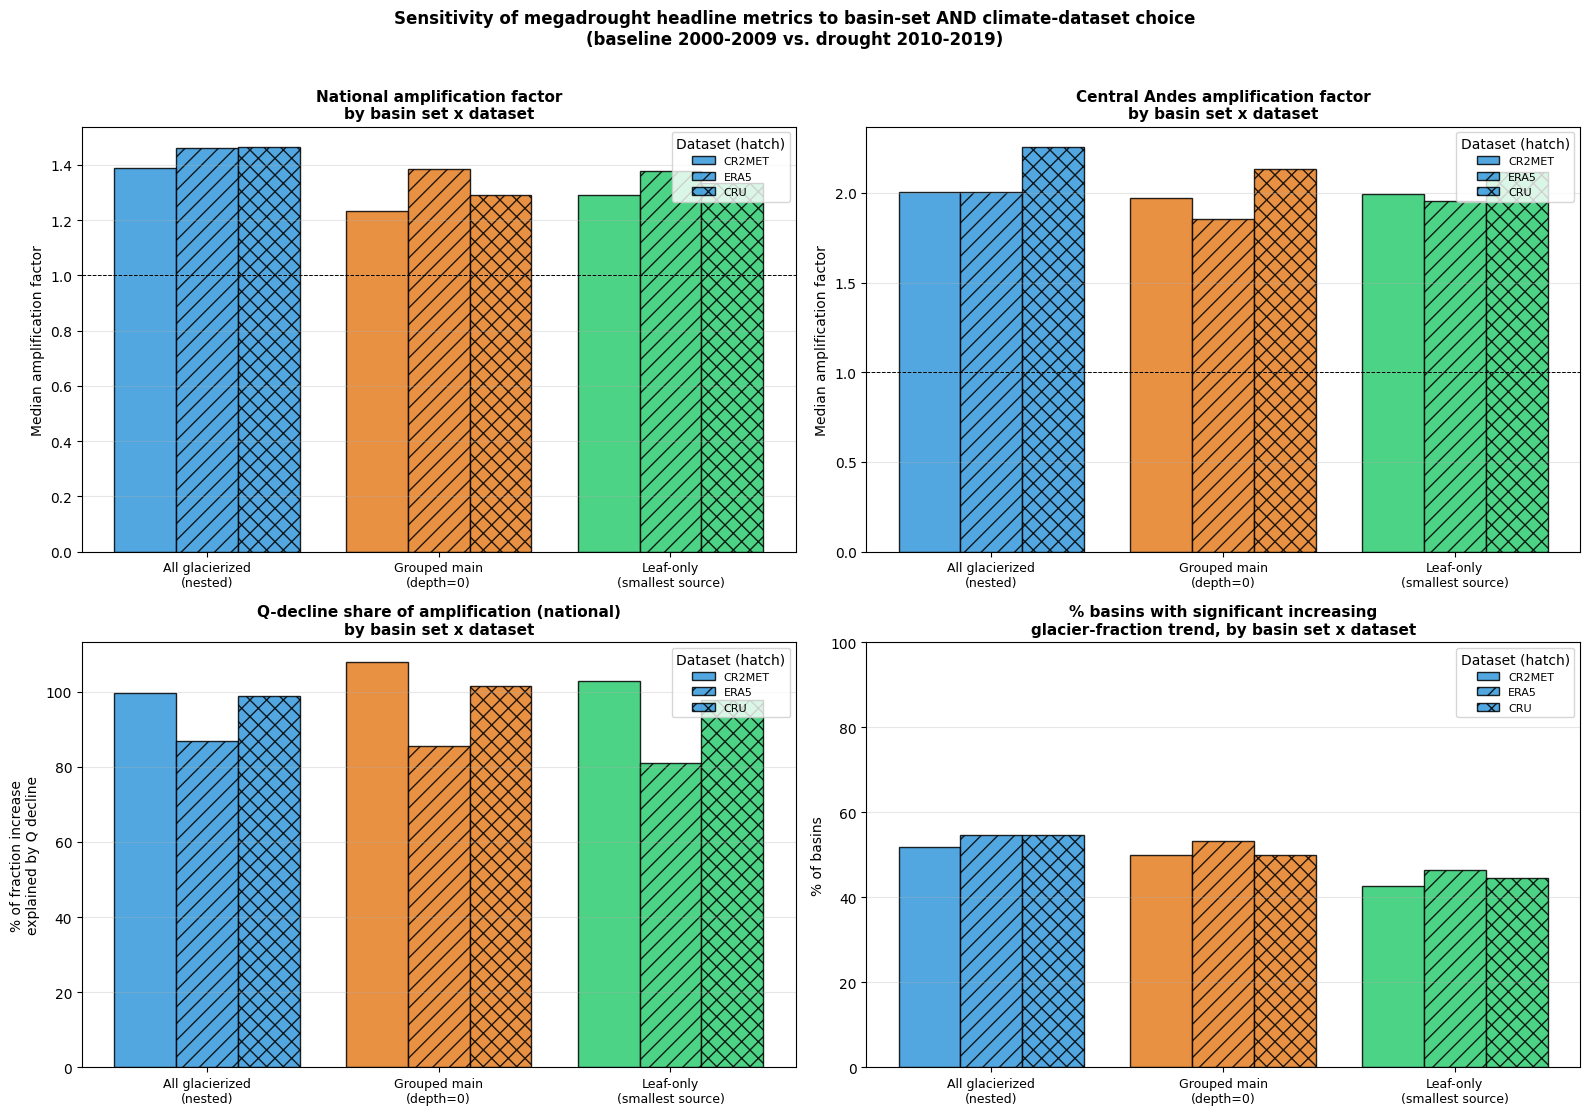

Saved: /Users/milliespencer/Desktop/CR2_OGGM_Paper/Output/basin_set_comparison/basin_set_dataset_comparison_figure.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))

basin_sets_order = ['all_glacierized', 'grouped_main', 'leaf_only']
DS_MARKERS = {'CR2MET': 'o', 'ERA5': 's', 'CRU': '^'}
DS_HATCH   = {'CR2MET': '', 'ERA5': '//', 'CRU': 'xx'}

x = np.arange(len(basin_sets_order))
n_ds = len(DATASETS)
w = 0.8 / n_ds

# Panel 1: median amplification factor, national -- grouped by basin set, bars per dataset
ax = axes[0, 0]
for j, ds in enumerate(DATASETS):
    vals = [df_summary.loc[(bs, ds), 'natl_median_amp'] for bs in basin_sets_order]
    offs = (j - (n_ds-1)/2) * w
    bars = ax.bar(x + offs, vals, w, color=[BASIN_SET_COLORS[bs] for bs in basin_sets_order],
                  hatch=DS_HATCH[ds], edgecolor='k', alpha=0.85, label=ds)
ax.set_xticks(x); ax.set_xticklabels([BASIN_SET_LABELS[bs] for bs in basin_sets_order], fontsize=9)
ax.set_ylabel('Median amplification factor', fontsize=10)
ax.set_title('National amplification factor\nby basin set x dataset', fontsize=11, fontweight='bold')
ax.axhline(1.0, color='k', lw=0.7, ls='--')
ax.legend(fontsize=8, title='Dataset (hatch)')
ax.grid(True, alpha=0.3, axis='y')

# Panel 2: median amplification factor, Central Andes
ax = axes[0, 1]
for j, ds in enumerate(DATASETS):
    vals = [df_summary.loc[(bs, ds), 'ca_median_amp'] for bs in basin_sets_order]
    offs = (j - (n_ds-1)/2) * w
    ax.bar(x + offs, vals, w, color=[BASIN_SET_COLORS[bs] for bs in basin_sets_order],
          hatch=DS_HATCH[ds], edgecolor='k', alpha=0.85, label=ds)
ax.set_xticks(x); ax.set_xticklabels([BASIN_SET_LABELS[bs] for bs in basin_sets_order], fontsize=9)
ax.set_ylabel('Median amplification factor', fontsize=10)
ax.set_title('Central Andes amplification factor\nby basin set x dataset', fontsize=11, fontweight='bold')
ax.axhline(1.0, color='k', lw=0.7, ls='--')
ax.legend(fontsize=8, title='Dataset (hatch)')
ax.grid(True, alpha=0.3, axis='y')

# Panel 3: Q-decline %, national -- grouped by basin set, bars per dataset
ax = axes[1, 0]
for j, ds in enumerate(DATASETS):
    vals = [df_summary.loc[(bs, ds), 'natl_pct_q_decline'] for bs in basin_sets_order]
    offs = (j - (n_ds-1)/2) * w
    ax.bar(x + offs, vals, w, color=[BASIN_SET_COLORS[bs] for bs in basin_sets_order],
          hatch=DS_HATCH[ds], edgecolor='k', alpha=0.85, label=ds)
ax.axhline(0, color='k', lw=0.7)
ax.set_xticks(x); ax.set_xticklabels([BASIN_SET_LABELS[bs] for bs in basin_sets_order], fontsize=9)
ax.set_ylabel('% of fraction increase\nexplained by Q decline', fontsize=10)
ax.set_title('Q-decline share of amplification (national)\nby basin set x dataset', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, title='Dataset (hatch)')
ax.grid(True, alpha=0.3, axis='y')

# Panel 4: % basins with significant increasing trend
ax = axes[1, 1]
for j, ds in enumerate(DATASETS):
    vals = [df_summary.loc[(bs, ds), 'pct_sig_increasing'] for bs in basin_sets_order]
    offs = (j - (n_ds-1)/2) * w
    ax.bar(x + offs, vals, w, color=[BASIN_SET_COLORS[bs] for bs in basin_sets_order],
          hatch=DS_HATCH[ds], edgecolor='k', alpha=0.85, label=ds)
ax.set_xticks(x); ax.set_xticklabels([BASIN_SET_LABELS[bs] for bs in basin_sets_order], fontsize=9)
ax.set_ylabel('% of basins', fontsize=10)
ax.set_title('% basins with significant increasing\nglacier-fraction trend, by basin set x dataset', fontsize=11, fontweight='bold')
ax.set_ylim(0, 100)
ax.legend(fontsize=8, title='Dataset (hatch)')
ax.grid(True, alpha=0.3, axis='y')

fig.suptitle('Sensitivity of megadrought headline metrics to basin-set AND climate-dataset choice\n'
             '(baseline 2000-2009 vs. drought 2010-2019)',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{COMPARISON_DIR}/basin_set_dataset_comparison_figure.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {COMPARISON_DIR}/basin_set_dataset_comparison_figure.png')


## Summary for co-author discussion

This table and figure directly show whether (and how much) the
megadrought headline numbers depend on basin-set choice:

- **Amplification factor** (national and Central Andes)
- **Q-decline vs. melt-change decomposition** (the mechanism split)
- **Max amplification factor** (how much a single outlier basin can
  swing the reported "up to Nx" figure)
- **% of basins with significant increasing trend** (the other
  headline claim from this notebook)

If the three basin sets agree closely, that's reassuring -- the
finding is robust to this methodological choice. If they diverge
substantially (as the Cell 27-29 discrepancy suggested), that's the
concrete evidence to bring to co-authors when deciding which basin
definition the paper should standardize on -- along with the tradeoffs
already documented elsewhere in this project:

- `all_glacierized`: most basins (largest n), but double-counts glacier
  signal across nested basin chains
- `grouped_main`: no double-counting, but averages glacier signal over
  much larger downstream catchments (dilutes extreme local signals)
- `leaf_only`: closest to the glacier source, no downstream dilution,
  but smallest sample size and likely most volatile/extreme ratios
